In [1]:
import os
from getdist import loadMCSamples, MCSamples, plots
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import matplotlib
%matplotlib inline


chain_root = "/home/weichen/cosmo_practice/chains/chains_kawas/hsc_lens_only_study"  
samples = loadMCSamples(
    chain_root,
    settings={"ignore_rows": 0.3}
)

print("# of weighted samples:", samples.weights.sum())
print("name of parameter:")
print(samples.getParamNames().list())

# of weighted samples: 384528.0
name of parameter:
['tau', 'ombh2', 'omch2', 'H0', 'ns', 'AIA', 'dm_0', 'dpz_0', 'logA', 'X1', 'X2', 'X3', 'b1', 'b2', 'b3', 'As', 'om_m', 'sigma8', 'S8_z_L1', 'S8_z_L2', 'S8_z_L3', 'minuslogprior', 'minuslogprior__0', 'chi2', 'chi2__test_hsc_lens.HSC_Lens']


In [2]:
p = samples.getParams()
S8 = p.sigma8 * np.sqrt(p.om_m / 0.3)

samples.addDerived(
    S8,
    name="S8",
    label="S_8"
)
samples.updateBaseStatistics()

In [3]:
params_to_report = [
    "om_m", "sigma8", "S8",
    "AIA", "dm_0", "dpz_0",
    "X1", "X2", "X3",
    "b1", "b2", "b3"
]
stats = samples.getMargeStats()
rows = []

for name in params_to_report:
    par = stats.parWithName(name)
    if par is None:
        print(f"{name} not in chain")
        continue

    interval68 = par.limits[0]
    rows.append({
        "parameter": name,
        "mean": par.mean,
        "std": par.err,
        "lower_68": interval68.lower,
        "upper_68": interval68.upper
    })
posterior_table = pd.DataFrame(rows)
display(posterior_table.round(5))

,parameter,mean,std,lower_68,upper_68
0,om_m,0.33626,0.04289,0.28975,0.37902
1,sigma8,0.70588,0.06272,0.63809,0.76268
2,S8,0.74278,0.04663,0.69350,0.78537
3,AIA,-0.04511,2.86017,-5.00000,5.00000
4,dm_0,0.00030,0.01009,-0.00984,0.01039
5,dpz_0,-0.05745,0.08708,-0.14320,0.02682
6,X1,1.09943,0.17394,0.92623,1.27229
7,X2,1.24091,0.13666,1.10574,1.37714
8,X3,1.17697,0.14499,1.02029,1.30328
9,b1,2.01700,0.37344,1.59827,2.27028


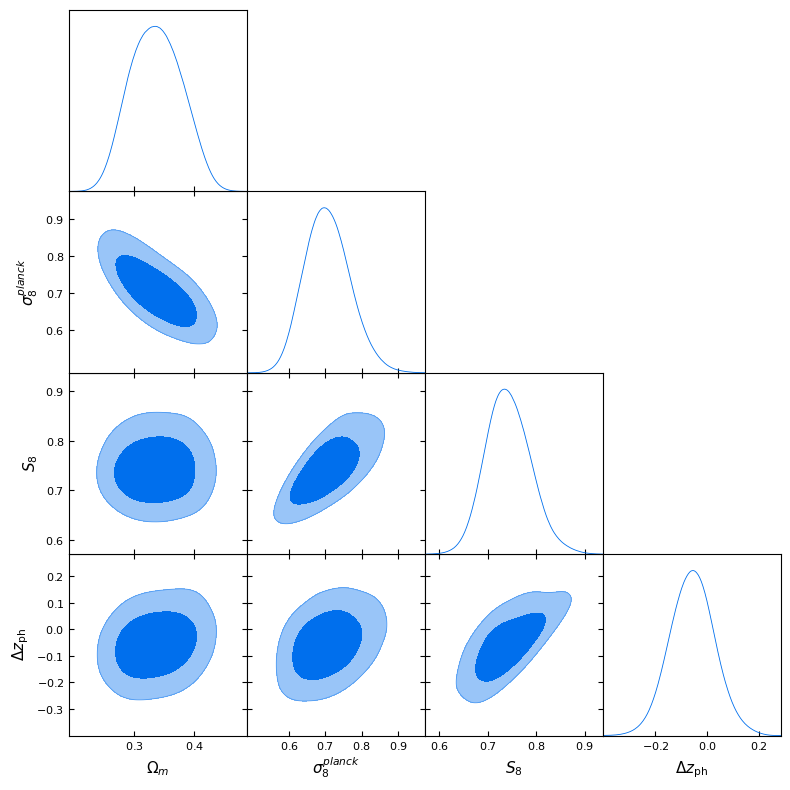

In [4]:
g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False

g.triangle_plot(
    [samples],
    ["om_m", "sigma8", "S8", "dpz_0"],
    filled=True
)
g.export("tri_om_m.png")

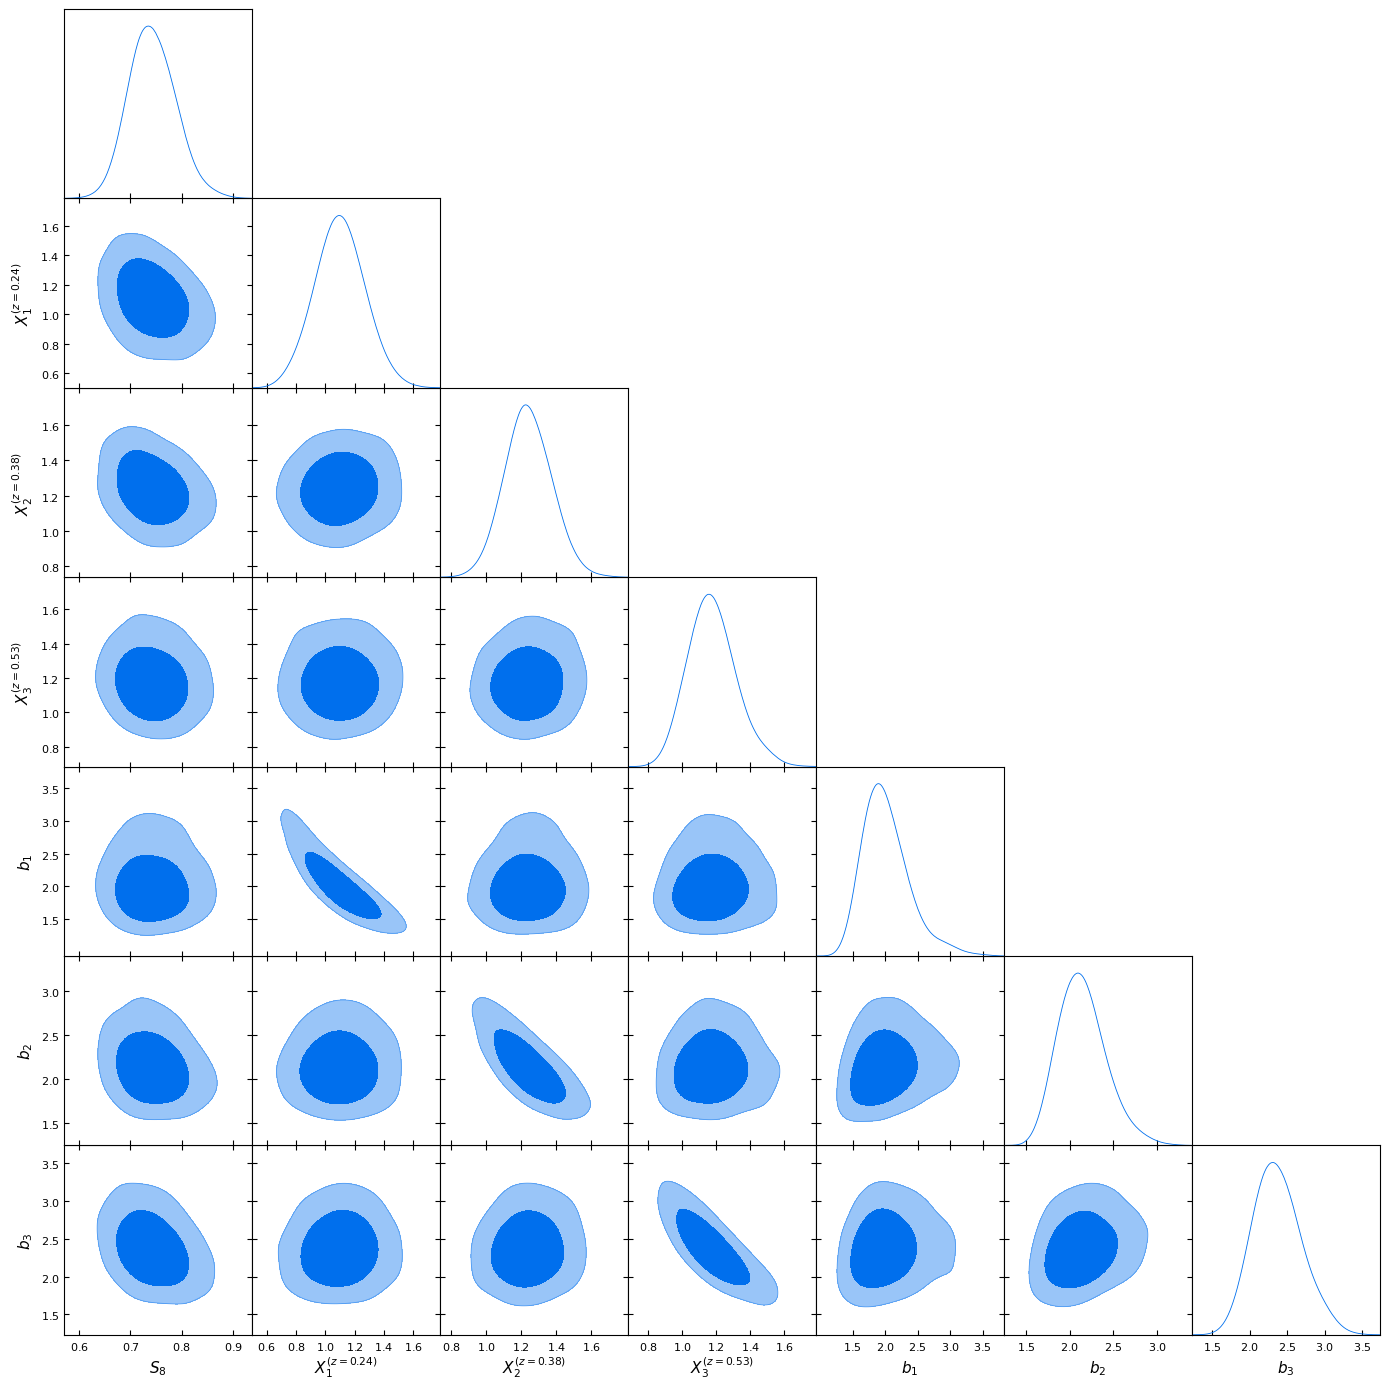

In [5]:
g = plots.get_subplot_plotter()
g.triangle_plot(
    [samples],
    ["S8", "X1", "X2", "X3", "b1", "b2", "b3"],
    filled=True
)
g.export("tri_mcmc.png")

In [6]:
corr_params = [
    "S8", "AIA", "dm_0", "dpz_0",
    "X1", "X2", "X3",
    "b1", "b2", "b3"
]

p = samples.getParams()
values = np.column_stack([getattr(p, name) for name in corr_params])
weights = samples.weights
mean = np.average(values, axis=0, weights=weights)
centered = values - mean
cov = ((centered * weights[:, None]).T @ centered / weights.sum())

# corr = cov / np.sqrt(np.outer(np.diag(cov), np.diag(cov)))
# corr_table = pd.DataFrame(
#     corr,
#     index=corr_params,
#     columns=corr_params
# )
# display(corr_table.round(2))

In [7]:
map_values = {
    "om_m": 0.29044466,
    "sigma8": 0.78272345,
    "S8": 0.78272345 * np.sqrt(0.29044466 / 0.3),
    "AIA": -0.79407104,
    "dm_0": 0.0011879888,
    "dpz_0": -0.029562746,
    "X1": 1.0584525,
    "X2": 1.1665719,
    "X3": 1.2463822
}

comparison_rows = []
for name, map_value in map_values.items():
    par = stats.parWithName(name)

    comparison_rows.append({
        "parameter": name,
        "MAP": map_value,
        "posterior_mean": par.mean,
        "posterior_std": par.err,
        "MAP_minus_mean_in_sigma":
            (map_value - par.mean) / par.err
    })

map_posterior_comparison = pd.DataFrame(comparison_rows)
display(map_posterior_comparison.round(4))

,parameter,MAP,posterior_mean,posterior_std,MAP_minus_mean_in_sigma
0,om_m,0.2904,0.3363,0.0429,-1.0682
1,sigma8,0.7827,0.7059,0.0627,1.2252
2,S8,0.7702,0.7428,0.0466,0.5871
3,AIA,-0.7941,-0.0451,2.8602,-0.2619
4,dm_0,0.0012,0.0003,0.0101,0.0881
5,dpz_0,-0.0296,-0.0574,0.0871,0.3202
6,X1,1.0585,1.0994,0.1739,-0.2356
7,X2,1.1666,1.2409,0.1367,-0.5440
8,X3,1.2464,1.1770,0.1450,0.4787


In [8]:
# ==========================================
# 1. define hsc data 處理的 fuction
# ==========================================
hsc_path = '/home/weichen/cosmo_practice/final_y3_chains'

def load_hsc_chain(file_prefix, label):
    txt_file = os.path.join(hsc_path, f"{file_prefix}.txt")
    names_file = os.path.join(hsc_path, f"{file_prefix}_paramnames.txt")
    
    if not os.path.exists(txt_file):
        print(f"跳過 {label}: can't find {txt_file}")
        return None

    names = []
    if os.path.exists(names_file):
        with open(names_file, 'r') as f:
            names = [line.split()[0] for line in f if line.strip()]
    else:
        with open(txt_file, 'r') as f:
            header = f.readline().strip()
            if header.startswith('#'):
                names = header.lstrip('#').split('\t')
            else:
                return None

    name_map = {
        'cosmological_parameters--omega_m': 'Omm',
        'COSMOLOGICAL_PARAMETERS--S_8': 'S8',
        'omega_m': 'Omm',
        'S_8': 'S8'
    }
    clean_names = [name_map.get(n.strip(), n.strip()) for n in names]

    data = np.loadtxt(txt_file)
    n_cols = data.shape[1]
    n_names = len(clean_names)
    
    weights = None
    if 'weight' in clean_names:
        w_idx = clean_names.index('weight')
        weights = data[:, w_idx]
    
    if n_cols > n_names:
        clean_data = data[:, :n_names]
    else:
        clean_data = data

    samples = MCSamples(
        samples=clean_data, 
        names=clean_names, 
        labels=clean_names,
        weights=weights,
        label=label,
        settings={'ignore_rows': 0.3}
    )
    return samples

print("loading hsc...")
hsc_configs = [
    ['hsc_y3_3x2pt_large_scale', '3x2pt large scale *', 'gray'],
    ['hsc_y3_3x2pt_small_scale', '3x2pt small scale', 'navy'],
    ['hsc_y3_real_cosmic_shear', 'Cosmic shear tomography: Real', 'green'],
    ['hsc_y3_fourier_cosmic_shear', 'Cosmic shear tomography: Fourier', 'firebrick']
]


loading hsc...


Removed 0.3 as burn in
[3x2pt large scale *] params: ['Ombh2', 'Omch2', 'Omde', 'ln10p10As', 'ns', 'b1_0', 'b1_1', 'b1_2', 'alphamag_0', 'alphamag_1', 'alphamag_2', 'dm_0', 'dpz_0', 'AIA', 'alphapsf', 'betapsf', 'Omm', 'sigma8', 'S8', 'signal_dSigma0_0', 'signal_dSigma0_1', 'signal_dSigma0_2', 'signal_dSigma0_3', 'signal_dSigma1_0', 'signal_dSigma1_1', 'signal_dSigma1_2', 'signal_dSigma1_3', 'signal_dSigma1_4', 'signal_dSigma2_0', 'signal_dSigma2_1', 'signal_dSigma2_2', 'signal_dSigma2_3', 'signal_dSigma2_4', 'signal_dSigma2_5', 'signal_dSigma2_6', 'signal_dSigma2_7', 'signal_xip_0', 'signal_xip_1', 'signal_xip_2', 'signal_xip_3', 'signal_xip_4', 'signal_xip_5', 'signal_xip_6', 'signal_xip_7', 'signal_xim_0', 'signal_xim_1', 'signal_xim_2', 'signal_xim_3', 'signal_xim_4', 'signal_xim_5', 'signal_xim_6', 'signal_wp0_0', 'signal_wp0_1', 'signal_wp0_2', 'signal_wp0_3', 'signal_wp0_4', 'signal_wp0_5', 'signal_wp0_6', 'signal_wp0_7', 'signal_wp0_8', 'signal_wp0_9', 'signal_wp0_10', 'signal_

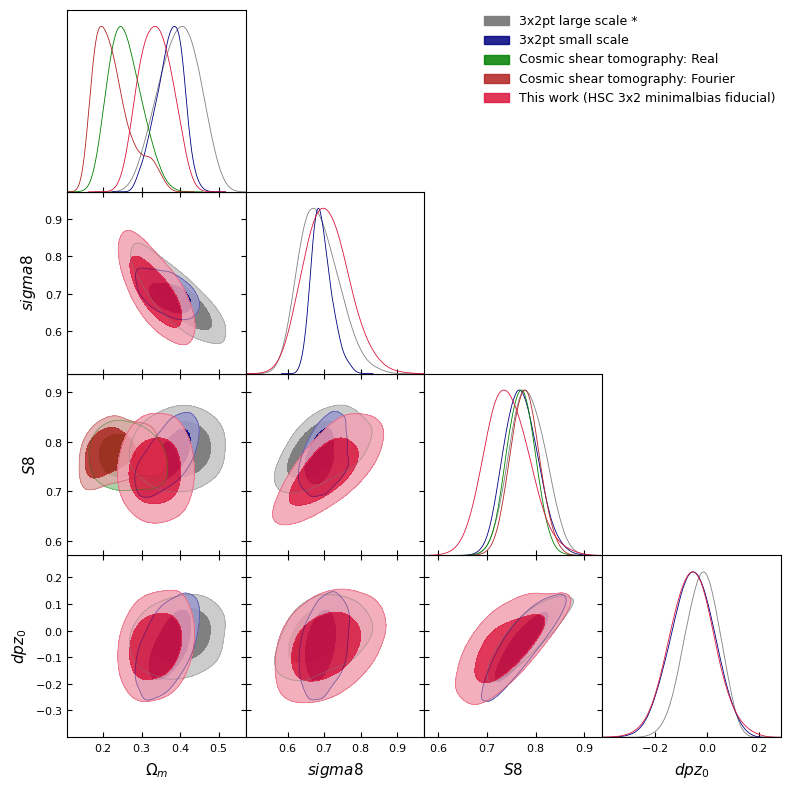

In [9]:
# 疊圖
import getdist.plots as plots

hsc_configs = [
    ['hsc_y3_3x2pt_large_scale', '3x2pt large scale *', 'gray'],
    ['hsc_y3_3x2pt_small_scale', '3x2pt small scale', 'navy'],
    ['hsc_y3_real_cosmic_shear', 'Cosmic shear tomography: Real', 'green'],
    ['hsc_y3_fourier_cosmic_shear', 'Cosmic shear tomography: Fourier', 'firebrick']
]

hsc_samples, hsc_labels, hsc_colors = [], [], []
for prefix, label, color in hsc_configs:
    s = load_hsc_chain(prefix, label)
    if s is None:
        continue
    names = s.getParamNames().list()
    print(f"[{label}] params:", names)

    renames = {}
    if 'Omm' in names:
        renames['Omm'] = 'om_m'
    for cand in ('sigma8', 'sigma_8', 'SIGMA8', 'cosmological_parameters--sigma_8'):
        if cand in names:
            renames[cand] = 'sigma8'
            break
    if renames:
        s.updateRenames(renames)

    hsc_samples.append(s)
    hsc_labels.append(label)
    hsc_colors.append(color)

samples_list = hsc_samples + [samples]
labels = hsc_labels + ['This work (HSC 3x2 minimalbias fiducial)']
colors = hsc_colors + ['crimson']

# 4) triangle plot
g = plots.get_subplot_plotter()
g.settings.figure_legend_frame = False

g.triangle_plot(
    samples_list,
    ['om_m', 'sigma8', 'S8', 'dpz_0'],
    filled=True,
    contour_colors=colors,
    legend_labels=labels,
    legend_loc='upper right',
)
g.export('tri_compare_hsc.png')